# V_ADD_STUDENT_DEGREE_STATUS preprocessing

Scope: schema fixes, null handling by approved business rules, quality flags, basic temporal parsing, and data-quality reports only. No model training, scaling, imputation, train/test split, course difficulty, or ML feature extraction.

## Cell 1: Imports and Raw Load

This cell loads the raw `V_ADD_STUDENT_DEGREE_STATUS` parquet from `RAW_DIR`, defines every output path used later, and shows the raw shape/dtypes before any cleaning. The raw dataframe is kept unchanged in `df_raw` for auditability.


In [ ]:
# Cell 1: imports and load
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.paths import RAW_DIR, ensure_parent

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

raw_path = RAW_DIR / "v_add_student_degree_status.parquet"
clean_path = RAW_DIR / "v_add_student_degree_status_clean.parquet"
null_report_path = RAW_DIR / "v_add_student_degree_status_null_report.csv"
degree_missing_report_path = RAW_DIR / "v_add_student_degree_status_missing_degree_report.csv"
dropped_missing_gpa_agpa_path = RAW_DIR / "v_add_student_degree_status_dropped_missing_gpa_agpa.csv"
duplicate_report_path = RAW_DIR / "v_add_student_degree_status_duplicate_report.csv"
logical_issue_report_path = RAW_DIR / "v_add_student_degree_status_logical_issue_report.csv"
quality_visual_path = RAW_DIR / "v_add_student_degree_status_quality_overview.png"

assert raw_path.exists(), f"Raw parquet not found: {raw_path}"

df_raw = pd.read_parquet(raw_path)

print("Raw path:", raw_path)
print("Raw shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.dtypes)

## Cell 2: Normalize Column Names

Column names are standardized to lowercase and stripped of accidental whitespace. Only the approved business columns are selected. `request_id` is intentionally excluded because it is not needed for this table.


In [18]:
# Cell 2: normalize column names
df = df_raw.copy()
# Keep the source values unchanged; only normalize the column labels for reliable selection.
df.columns = df.columns.astype(str).str.strip().str.lower()

keep_columns = [
    "student_status_id",
    "student_id",
    "part_id",
    "degree_id",
    "study_mode",
    "gpa_percent",
    "gpa_points",
    "start_part_id",
    "finish_part_id",
    "start_agpa_percent",
    "start_agpa_points",
    "end_agpa_percent",
    "end_agpa_points",
    "semester_reg_courses",
    "semester_reg_credits",
    "semester_pass_courses",
    "semester_pass_credits",
    "semester_fail_courses",
    "semester_fail_credits",
    "total_pass_courses",
    "total_pass_credits",
    "total_fail_courses",
    "total_fail_credits",
    "reg_total_semesters",
    "finish_status",
    "version_title_sl",
    "start_level_id",
    "start_level_name_pl",
]

missing_required_columns = sorted(set(keep_columns) - set(df.columns))
extra_source_columns = sorted(set(df.columns) - set(keep_columns))

print("Missing required columns:", missing_required_columns)
print("Extra source columns that will not be kept:", extra_source_columns)

assert not missing_required_columns, f"Missing required columns: {missing_required_columns}"
assert "request_id" in df.columns, "Expected request_id in raw source so it can be intentionally dropped."

# Select only approved columns. This is where request_id is intentionally removed.
df = df[keep_columns].copy()

print("Selected shape after dropping request_id and non-approved columns:", df.shape)
display(df.head())

Missing required columns: []
Extra source columns that will not be kept: ['request_id']
Selected shape after dropping request_id and non-approved columns: (154779, 28)


,student_status_id,student_id,part_id,degree_id,study_mode,gpa_percent,gpa_points,start_part_id,finish_part_id,start_agpa_percent,start_agpa_points,end_agpa_percent,end_agpa_points,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,reg_total_semesters,finish_status,version_title_sl,start_level_id,start_level_name_pl
0,340275.111,28401.111,20222.0,1.111,C,84.25,3.16,20221.0,NaN,89.07,3.34,86.24,3.24,8.0,21.0,7.0,20.0,0.0,0.0,5.0,14.0,0.0,0.0,2.0,NaN,القرار رقم 230,595.111,First Year
1,334725.111,28401.111,20221.0,1.111,C,89.07,3.34,20221.0,NaN,0.00,0.00,89.07,3.34,5.0,14.0,5.0,14.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,القرار رقم 230,595.111,First Year
2,353697.111,28401.111,20231.0,1.111,C,85.28,3.15,20221.0,NaN,86.24,3.24,85.90,3.21,8.0,20.0,7.0,18.0,0.0,0.0,12.0,34.0,0.0,0.0,3.0,NaN,القرار رقم 230,596.111,Second Year
3,361412.111,28401.111,20232.0,1.111,C,85.45,3.18,20221.0,NaN,85.90,3.21,85.78,3.20,9.0,20.0,9.0,20.0,0.0,0.0,19.0,52.0,0.0,0.0,4.0,NaN,القرار رقم 230,596.111,Second Year
4,374249.111,28401.111,20241.0,1.111,C,88.41,3.31,20221.0,NaN,85.78,3.20,86.28,3.22,9.0,17.0,9.0,17.0,0.0,0.0,28.0,72.0,0.0,0.0,5.0,NaN,القرار رقم 230,597.111,Third year


## Cell 3: Define Schema Groups

Columns are grouped by business meaning before conversion. This keeps the schema rules explicit: suffix IDs stay as strings, academic part IDs become nullable integers, GPA/AGPA and credits stay numeric, and text fields use pandas string dtype.


In [19]:
# Cell 3: define schema groups
suffix_id_cols = [
    "student_status_id",
    "student_id",
    "degree_id",
    "start_level_id",
]

part_id_cols = [
    "part_id",
    "start_part_id",
    "finish_part_id",
]

gpa_agpa_cols = [
    "gpa_percent",
    "gpa_points",
    "start_agpa_percent",
    "start_agpa_points",
    "end_agpa_percent",
    "end_agpa_points",
]

percent_cols = [
    "gpa_percent",
    "start_agpa_percent",
    "end_agpa_percent",
]

credit_cols = [
    "semester_reg_credits",
    "semester_pass_credits",
    "semester_fail_credits",
    "total_pass_credits",
    "total_fail_credits",
]

course_count_cols = [
    "semester_reg_courses",
    "semester_pass_courses",
    "semester_fail_courses",
    "total_pass_courses",
    "total_fail_courses",
    "reg_total_semesters",
]

text_cols = [
    "study_mode",
    "finish_status",
    "version_title_sl",
    "start_level_name_pl",
]

degree_null_check_cols = [
    "gpa_percent",
    "gpa_points",
    "start_agpa_percent",
    "start_agpa_points",
    "end_agpa_percent",
    "end_agpa_points",
    "semester_reg_courses",
    "semester_reg_credits",
    "semester_pass_courses",
    "semester_pass_credits",
    "semester_fail_courses",
    "semester_fail_credits",
    "total_pass_courses",
    "total_pass_credits",
    "total_fail_courses",
    "total_fail_credits",
]

print("Schema groups defined.")

Schema groups defined.


## Cell 4: Helper Conversion Functions

These helpers make type conversion strict and repeatable. Numeric conversion asserts that values are really numeric, integer conversion rejects fractional values, and the null-report helper creates the same reporting structure every time.


In [ ]:
# Cell 4: helper conversion functions
def to_pandas_string(series: pd.Series, *, strip: bool = False) -> pd.Series:
    """Convert to pandas StringDtype. For suffix IDs, do not alter decimal suffixes."""
    out = series.astype("string")
    if strip:
        out = out.str.strip()
    return out


def to_nullable_float(series: pd.Series, column_name: str) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    bad_non_numeric = series.notna() & numeric.isna() ##NOT A NUMBER 
    assert not bad_non_numeric.any(), f"{column_name} contains non-numeric values." ## Check if there is a non number then raise an error with the column name
    return numeric.astype("Float64")


def to_nullable_int(series: pd.Series, column_name: str) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    bad_non_numeric = series.notna() & numeric.isna()
    assert not bad_non_numeric.any(), f"{column_name} contains non-numeric values."

    fractional = numeric.notna() & (numeric % 1 != 0)
    assert not fractional.any(), f"{column_name} contains fractional values; cannot safely cast to Int64."

    return numeric.astype("Int64")


def build_null_report(frame: pd.DataFrame) -> pd.DataFrame:
    row_count = len(frame)
    null_count = frame.isna().sum()
    return (
        pd.DataFrame(
            {
                "column": frame.columns,
                "dtype": [str(dtype) for dtype in frame.dtypes],
                "null_count": [int(null_count[col]) for col in frame.columns],
                "null_percent": [round(float(null_count[col] / row_count * 100), 4) if row_count else 0.0 for col in frame.columns],
            }
        )
        .sort_values(["null_count", "column"], ascending=[False, True])
        .reset_index(drop=True)
    )


def extract_part_components(series: pd.Series) -> tuple[pd.Series, pd.Series]:
    year = (series // 10).astype("Int64")
    semester_no = (series % 10).astype("Int64")
    return year, semester_no


print("Helper functions ready.")

Helper functions ready.


## Cell 5: Apply Schema

This cell applies the confirmed schema decisions. It also checks that `student_status_id` is present and unique, and verifies that every expected dtype was applied correctly.


In [21]:
# Cell 5: apply schema
# Suffix IDs such as 340275.111 are identifiers, not decimals to round or cast to integers.
for col in suffix_id_cols:
    df[col] = to_pandas_string(df[col], strip=False)

# Academic part IDs are term codes like 20221, so nullable Int64 is appropriate.
for col in part_id_cols:
    df[col] = to_nullable_int(df[col], col)

# GPA/AGPA and credit values can contain decimals, so they remain Float64.
for col in gpa_agpa_cols + credit_cols:
    df[col] = to_nullable_float(df[col], col)

# Counts were previously checked as whole numbers and are stored as nullable Int64.
for col in course_count_cols:
    df[col] = to_nullable_int(df[col], col)

for col in text_cols:
    df[col] = to_pandas_string(df[col], strip=True)

assert df["student_status_id"].notna().all(), "student_status_id has null values."
assert df["student_status_id"].is_unique, "student_status_id must be unique."

expected_dtypes = {
    **{col: "string" for col in suffix_id_cols + text_cols},
    **{col: "Int64" for col in part_id_cols + course_count_cols},
    **{col: "Float64" for col in gpa_agpa_cols + credit_cols},
}

dtype_check = pd.DataFrame(
    {
        "column": list(expected_dtypes),
        "expected_dtype": list(expected_dtypes.values()),
        "actual_dtype": [str(df[col].dtype) for col in expected_dtypes],
    }
)
dtype_check["matches"] = dtype_check["expected_dtype"].eq(dtype_check["actual_dtype"])

display(dtype_check)
assert dtype_check["matches"].all(), "One or more columns failed dtype conversion."

print("Schema applied and primary-key uniqueness confirmed.")

,column,expected_dtype,actual_dtype,matches
0,student_status_id,string,string,True
1,student_id,string,string,True
2,degree_id,string,string,True
3,start_level_id,string,string,True
4,study_mode,string,string,True
5,finish_status,string,string,True
6,version_title_sl,string,string,True
7,start_level_name_pl,string,string,True
8,part_id,Int64,Int64,True
9,start_part_id,Int64,Int64,True


Schema applied and primary-key uniqueness confirmed.


## Cell 6: Null Report

The first null report is created after schema conversion and before business-rule drops. This makes the missing-value profile visible while the data is still as close as possible to the raw source.


In [22]:
# Cell 6: null report
null_report_before_business_drops = build_null_report(df)

display(null_report_before_business_drops)

print("Rows:", len(df))
print("Columns with nulls:", int((null_report_before_business_drops["null_count"] > 0).sum()))

,column,dtype,null_count,null_percent
0,finish_part_id,Int64,46900,30.3013
1,finish_status,string,46608,30.1126
2,degree_id,string,2126,1.3736
3,start_level_id,string,2119,1.3690
4,reg_total_semesters,Int64,617,0.3986
5,end_agpa_percent,Float64,11,0.0071
6,end_agpa_points,Float64,11,0.0071
7,gpa_percent,Float64,11,0.0071
8,gpa_points,Float64,11,0.0071
9,semester_fail_courses,Int64,11,0.0071


Rows: 154779
Columns with nulls: 23


## Cell 7: Business Flags

Nulls that are meaningful are converted into explicit quality/business flags instead of being dropped. This is where unfinished students, missing degree candidates, and unknown registration-semester totals are documented.


In [23]:
# Cell 7: business flags
# Missing finish values are normal for active/not-finished students, so they become flags.
df["flag_is_finished"] = (df["finish_part_id"].notna() | df["finish_status"].notna()).astype("boolean")
df["flag_missing_finish_part_id"] = df["finish_part_id"].isna().astype("boolean")
df["flag_missing_finish_status"] = df["finish_status"].isna().astype("boolean")

df["flag_missing_degree_id"] = df["degree_id"].isna().astype("boolean")

# Missing degree_id candidates should have no GPA, course, or credit activity.
degree_null_zero_activity = df[degree_null_check_cols].fillna(0).eq(0).all(axis=1)
df["flag_registered_without_degree_or_courses_candidate"] = (
    df["flag_missing_degree_id"] & degree_null_zero_activity
).astype("boolean")

df["flag_missing_reg_total_semesters"] = df["reg_total_semesters"].isna().astype("boolean")
# Keep the numeric column numeric; store unknown/known status in a companion string column.
df["reg_total_semesters_status"] = np.where(
    df["reg_total_semesters"].notna(),
    "known",
    "unknown",
)
df["reg_total_semesters_status"] = df["reg_total_semesters_status"].astype("string")

flag_summary = pd.DataFrame(
    {
        "flag": [
            "flag_is_finished",
            "flag_missing_finish_part_id",
            "flag_missing_finish_status",
            "flag_missing_degree_id",
            "flag_registered_without_degree_or_courses_candidate",
            "flag_missing_reg_total_semesters",
        ],
        "true_count": [
            int(df[col].fillna(False).sum())
            for col in [
                "flag_is_finished",
                "flag_missing_finish_part_id",
                "flag_missing_finish_status",
                "flag_missing_degree_id",
                "flag_registered_without_degree_or_courses_candidate",
                "flag_missing_reg_total_semesters",
            ]
        ],
    }
)

display(flag_summary)
display(df["reg_total_semesters_status"].value_counts(dropna=False).rename_axis("status").reset_index(name="rows"))

,flag,true_count
0,flag_is_finished,108175
1,flag_missing_finish_part_id,46900
2,flag_missing_finish_status,46608
3,flag_missing_degree_id,2126
4,flag_registered_without_degree_or_courses_cand...,2126
5,flag_missing_reg_total_semesters,617


,status,rows
0,known,154162
1,unknown,617


## Cell 8: Inspect and Drop Missing GPA/AGPA Rows

The only approved row drop happens here. Rows with missing GPA/AGPA values are displayed and saved to a report before being removed from the clean dataframe.


In [ ]:
# Cell 8: inspect and drop missing GPA/AGPA rows
# Business-approved bad rows: any missing GPA/AGPA value means the row is excluded.
missing_gpa_agpa_mask = df[gpa_agpa_cols].isna().any(axis=1)
dropped_missing_gpa_agpa_report = df.loc[missing_gpa_agpa_mask].copy()

print("Rows with missing GPA/AGPA values to drop:", len(dropped_missing_gpa_agpa_report))
display(dropped_missing_gpa_agpa_report)

df_clean = df.loc[~missing_gpa_agpa_mask].copy()

assert df_clean[gpa_agpa_cols].notna().all().all(), "GPA/AGPA nulls remain after approved drop."
assert len(df_clean) + len(dropped_missing_gpa_agpa_report) == len(df)
assert df_clean["student_status_id"].is_unique, "student_status_id duplicate appeared after GPA/AGPA drop."

print("Shape before drop:", df.shape)   
print("Shape after drop:", df_clean.shape)

Rows with missing GPA/AGPA values to drop: 11


,student_status_id,student_id,part_id,degree_id,study_mode,gpa_percent,gpa_points,start_part_id,finish_part_id,start_agpa_percent,start_agpa_points,end_agpa_percent,end_agpa_points,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,reg_total_semesters,finish_status,version_title_sl,start_level_id,start_level_name_pl,flag_is_finished,flag_missing_finish_part_id,flag_missing_finish_status,flag_missing_degree_id,flag_registered_without_degree_or_courses_candidate,flag_missing_reg_total_semesters,reg_total_semesters_status
407,334317.111,28016.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown
132937,334382.111,28081.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown
142910,334572.111,28271.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown
142966,334580.111,28279.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown
142985,334584.111,28283.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown
143175,334508.111,28207.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown
143267,334492.111,28191.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown
143268,334493.111,28192.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown
143804,334561.111,28260.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown
143894,334515.111,28214.111,20221,<NA>,C,<NA>,<NA>,20221,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,First Year,False,True,True,True,True,True,unknown


Shape before drop: (154779, 35)
Shape after drop: (154768, 35)


## Cell 9: Missing `degree_id` Analysis

Rows with missing `degree_id` are not dropped. This section verifies the business expectation that these retained rows have zero GPA/AGPA, course-count, and credit values in the checked columns.


In [25]:
# Cell 9: degree_id null analysis
degree_missing_report = df_clean.loc[df_clean["degree_id"].isna()].copy()

degree_null_non_zero_mask = degree_missing_report[degree_null_check_cols].fillna(0).ne(0).any(axis=1)
degree_null_non_zero_report = degree_missing_report.loc[degree_null_non_zero_mask].copy()

degree_null_summary = pd.DataFrame(
    {
        "metric": [
            "degree_id_null_rows",
            "degree_id_null_rows_with_any_non_zero_gpa_agpa_course_or_credit_value",
            "registered_without_degree_or_courses_candidate_rows",
        ],
        "value": [
            len(degree_missing_report),
            len(degree_null_non_zero_report),
            int(df_clean["flag_registered_without_degree_or_courses_candidate"].fillna(False).sum()),
        ],
    }
)

display(degree_null_summary)
display(degree_missing_report[degree_null_check_cols].describe().T)

if len(degree_null_non_zero_report):
    print("Rows needing business review because degree_id is null but checked values are non-zero:")
    display(degree_null_non_zero_report)
else:
    print("All retained degree_id-null rows have zero GPA/AGPA, course-count, and credit values in checked columns.")

,metric,value
0,degree_id_null_rows,2115
1,degree_id_null_rows_with_any_non_zero_gpa_agpa...,0
2,registered_without_degree_or_courses_candidate...,2115


,count,mean,std,min,25%,50%,75%,max
gpa_percent,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gpa_points,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
start_agpa_percent,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
start_agpa_points,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
end_agpa_percent,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
end_agpa_points,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
semester_reg_courses,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
semester_reg_credits,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
semester_pass_courses,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
semester_pass_credits,2115.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


All retained degree_id-null rows have zero GPA/AGPA, course-count, and credit values in checked columns.


## Cell 10: Academic Part Parsing

The academic year and semester number are parsed from `part_id`, `start_part_id`, and `finish_part_id`. Invalid semester numbers are flagged for review rather than removed.


In [26]:
# Cell 10: part_id temporal extraction
df_clean["part_year"], df_clean["part_semester_no"] = extract_part_components(df_clean["part_id"])
df_clean["start_part_year"], df_clean["start_part_semester_no"] = extract_part_components(df_clean["start_part_id"])
df_clean["finish_part_year"], df_clean["finish_part_semester_no"] = extract_part_components(df_clean["finish_part_id"])

# Expected semester numbers are flagged when outside this set, but rows are retained.
valid_semester_numbers = {1, 2, 3, 4}

df_clean["flag_invalid_part_id"] = (
    df_clean["part_semester_no"].notna() & ~df_clean["part_semester_no"].isin(valid_semester_numbers)
).astype("boolean")
df_clean["flag_invalid_start_part_id"] = (
    df_clean["start_part_semester_no"].notna() & ~df_clean["start_part_semester_no"].isin(valid_semester_numbers)
).astype("boolean")
df_clean["flag_invalid_finish_part_id"] = (
    df_clean["finish_part_semester_no"].notna() & ~df_clean["finish_part_semester_no"].isin(valid_semester_numbers)
).astype("boolean")

part_validation_summary = pd.DataFrame(
    {
        "check": ["part_id", "start_part_id", "finish_part_id"],
        "invalid_rows": [
            int(df_clean["flag_invalid_part_id"].sum()),
            int(df_clean["flag_invalid_start_part_id"].sum()),
            int(df_clean["flag_invalid_finish_part_id"].sum()),
        ],
    }
)
display(part_validation_summary)

student_part_context = (
    df_clean.groupby("student_id", dropna=False)
    .agg(
        first_part_id=("part_id", "min"),
        last_part_id=("part_id", "max"),
        first_part_year=("part_year", "min"),
        last_part_year=("part_year", "max"),
        rows=("student_status_id", "count"),
        missing_reg_total_semesters_rows=("flag_missing_reg_total_semesters", "sum"),
    )
    .reset_index()
)

print("Students with missing reg_total_semesters, with first/last part context:")
display(student_part_context.loc[student_part_context["missing_reg_total_semesters_rows"] > 0].head(50))

,check,invalid_rows
0,part_id,0
1,start_part_id,0
2,finish_part_id,144


Students with missing reg_total_semesters, with first/last part context:


,student_id,first_part_id,last_part_id,first_part_year,last_part_year,rows,missing_reg_total_semesters_rows
7034,1844.111,20111,20162,2011,2016,12,12
7123,1862.111,20111,20162,2011,2016,12,12
7161,1870.111,20111,20162,2011,2016,20,20
7247,1886.111,20111,20161,2011,2016,15,15
7271,1891.111,20111,20161,2011,2016,15,15
7308,1897.111,20111,20162,2011,2016,20,20
7368,1909.111,20111,20162,2011,2016,19,19
7901,2009.111,20121,20161,2012,2016,13,13
10369,249.111,20131,20161,2013,2016,9,9
11697,296.111,20121,20161,2012,2016,15,15


## Cell 11: Duplicate Checks

This section checks full-row duplicates, primary-key duplicates, and the useful logical key `student_id + part_id + degree_id`. Duplicate reports are only saved when duplicates exist.


In [27]:
# Cell 11: duplicate checks
full_duplicate_rows = df_clean.loc[df_clean.duplicated(keep=False)].copy()
duplicate_student_status_id_rows = df_clean.loc[df_clean.duplicated("student_status_id", keep=False)].copy()
duplicate_logical_key_rows = df_clean.loc[
    df_clean.duplicated(["student_id", "part_id", "degree_id"], keep=False)
].copy()

duplicate_summary = pd.DataFrame(
    {
        "check": [
            "full_duplicate_rows",
            "duplicate_student_status_id_rows",
            "duplicate_student_id_part_id_degree_id_rows",
        ],
        "duplicate_rows": [
            len(full_duplicate_rows),
            len(duplicate_student_status_id_rows),
            len(duplicate_logical_key_rows),
        ],
    }
)

display(duplicate_summary)

duplicate_reports = []
if len(full_duplicate_rows):
    duplicate_reports.append(full_duplicate_rows.assign(duplicate_check="full_duplicate_rows"))
if len(duplicate_student_status_id_rows):
    duplicate_reports.append(duplicate_student_status_id_rows.assign(duplicate_check="duplicate_student_status_id_rows"))
if len(duplicate_logical_key_rows):
    duplicate_reports.append(duplicate_logical_key_rows.assign(duplicate_check="duplicate_student_id_part_id_degree_id_rows"))

duplicate_report = pd.concat(duplicate_reports, ignore_index=True) if duplicate_reports else pd.DataFrame()

assert len(duplicate_student_status_id_rows) == 0, "student_status_id duplicates found in clean dataframe."

if len(duplicate_report):
    display(duplicate_report)
else:
    print("No duplicate rows found for the configured duplicate checks.")

,check,duplicate_rows
0,full_duplicate_rows,0
1,duplicate_student_status_id_rows,0
2,duplicate_student_id_part_id_degree_id_rows,0


No duplicate rows found for the configured duplicate checks.


## Cell 12: Logical Checks

This section searches for negative credits/counts, percentages outside 0-100, and invalid academic-part flags. These are reported and flagged only; no additional rows are removed.


In [28]:
# Cell 12: logical checks
logical_issue_frames = []

for col in credit_cols:
    mask = df_clean[col] < 0
    if mask.any():
        logical_issue_frames.append(df_clean.loc[mask].assign(logical_check=f"negative_{col}"))

for col in course_count_cols:
    mask = df_clean[col] < 0
    if mask.any():
        logical_issue_frames.append(df_clean.loc[mask].assign(logical_check=f"negative_{col}"))

for col in percent_cols:
    mask = df_clean[col].notna() & ((df_clean[col] < 0) | (df_clean[col] > 100))
    if mask.any():
        logical_issue_frames.append(df_clean.loc[mask].assign(logical_check=f"percent_outside_0_100_{col}"))

for flag_col in ["flag_invalid_part_id", "flag_invalid_start_part_id", "flag_invalid_finish_part_id"]:
    mask = df_clean[flag_col].fillna(False)
    if mask.any():
        logical_issue_frames.append(df_clean.loc[mask].assign(logical_check=flag_col))

logical_issue_report = pd.concat(logical_issue_frames, ignore_index=True) if logical_issue_frames else pd.DataFrame()

logical_check_summary = pd.DataFrame(
    [
        {"check": f"negative_{col}", "rows": int((df_clean[col] < 0).sum())}
        for col in credit_cols + course_count_cols
    ]
    + [
        {
            "check": f"percent_outside_0_100_{col}",
            "rows": int((df_clean[col].notna() & ((df_clean[col] < 0) | (df_clean[col] > 100))).sum()),
        }
        for col in percent_cols
    ]
    + [
        {"check": flag_col, "rows": int(df_clean[flag_col].fillna(False).sum())}
        for flag_col in ["flag_invalid_part_id", "flag_invalid_start_part_id", "flag_invalid_finish_part_id"]
    ]
)

display(logical_check_summary)

if len(logical_issue_report):
    display(logical_issue_report.head(100))
else:
    print("No logical issues found for negative numeric values, percentage bounds, or invalid part semesters.")

,check,rows
0,negative_semester_reg_credits,0
1,negative_semester_pass_credits,0
2,negative_semester_fail_credits,0
3,negative_total_pass_credits,0
4,negative_total_fail_credits,0
5,negative_semester_reg_courses,0
6,negative_semester_pass_courses,0
7,negative_semester_fail_courses,0
8,negative_total_pass_courses,0
9,negative_total_fail_courses,0


,student_status_id,student_id,part_id,degree_id,study_mode,gpa_percent,gpa_points,start_part_id,finish_part_id,start_agpa_percent,start_agpa_points,end_agpa_percent,end_agpa_points,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,reg_total_semesters,finish_status,version_title_sl,start_level_id,start_level_name_pl,flag_is_finished,flag_missing_finish_part_id,flag_missing_finish_status,flag_missing_degree_id,flag_registered_without_degree_or_courses_candidate,flag_missing_reg_total_semesters,reg_total_semesters_status,part_year,part_semester_no,start_part_year,start_part_semester_no,finish_part_year,finish_part_semester_no,flag_invalid_part_id,flag_invalid_start_part_id,flag_invalid_finish_part_id,logical_check
0,205769.111,3269.111,20131,13.111,C,0.0,0.0,20131,20130,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,WITHDRAWN,القرار رقم 230,29.111,First Year,True,False,False,False,False,False,known,2013,1,2013,1,2013,0,False,False,True,flag_invalid_finish_part_id
1,136711.111,3187.111,20111,13.111,C,0.0,0.0,20111,20110,20.0,0.0,20.0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,WITHDRAWN,القرار الوزاري الموحد,29.111,First Year,True,False,False,False,False,False,known,2011,1,2011,1,2011,0,False,False,True,flag_invalid_finish_part_id
2,215370.111,9980.111,20151,1.111,C,0.0,0.0,20151,20150,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,WITHDRAWN,القرار رقم 230,19.111,First Year,True,False,False,False,False,False,known,2015,1,2015,1,2015,0,False,False,True,flag_invalid_finish_part_id
3,137343.111,9934.111,20151,13.111,C,0.0,0.0,20151,20150,0.0,0.0,0.0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,WITHDRAWN,القرار رقم 230,29.111,First Year,True,False,False,False,False,False,known,2015,1,2015,1,2015,0,False,False,True,flag_invalid_finish_part_id
4,173780.111,6856.111,20111,16.111,C,63.89,2.11,20111,20110,0.0,0.0,63.89,2.11,7,18.0,7,18.0,0,0.0,0,0.0,0,0.0,1,CHANGE_FACULTY,القرار رقم 230,145.111,First Year,True,False,False,False,False,False,known,2011,1,2011,1,2011,0,False,False,True,flag_invalid_finish_part_id
5,173781.111,6856.111,20112,16.111,C,57.06,1.45,20111,20110,63.89,2.11,60.68,1.8,6,16.0,4,12.0,2,4.0,7,18.0,0,0.0,2,CHANGE_FACULTY,القرار رقم 230,145.111,First Year,True,False,False,False,False,False,known,2011,2,2011,1,2011,0,False,False,True,flag_invalid_finish_part_id
6,140091.111,6856.111,20122,16.111,C,0.0,0.0,20111,20110,60.68,1.8,60.68,1.8,0,0.0,0,0.0,0,0.0,11,30.0,2,4.0,2,CHANGE_FACULTY,القرار رقم 230,146.111,Second Year,True,False,False,False,False,False,known,2012,2,2011,1,2011,0,False,False,True,flag_invalid_finish_part_id
7,146223.111,6856.111,20121,16.111,C,0.0,0.0,20111,20110,60.68,1.8,60.68,1.8,0,0.0,0,0.0,0,0.0,11,30.0,2,4.0,2,CHANGE_FACULTY,القرار رقم 230,146.111,Second Year,True,False,False,False,False,False,known,2012,1,2011,1,2011,0,False,False,True,flag_invalid_finish_part_id
8,205842.111,6856.111,20132,16.111,C,0.0,0.0,20111,20110,60.68,1.8,60.68,1.8,0,0.0,0,0.0,0,0.0,11,30.0,2,4.0,2,CHANGE_FACULTY,القرار رقم 230,146.111,Second Year,True,False,False,False,False,False,known,2013,2,2011,1,2011,0,False,False,True,flag_invalid_finish_part_id
9,213921.111,6856.111,20131,16.111,C,0.0,0.0,20111,20110,60.68,1.8,60.68,1.8,0,0.0,0,0.0,0,0.0,11,30.0,2,4.0,2,CHANGE_FACULTY,القرار رقم 230,146.111,Second Year,True,False,False,False,False,False,known,2013,1,2011,1,2011,0,False,False,True,flag_invalid_finish_part_id


## Cell 13: Final Column Ordering

The final dataframe is arranged into a stable, readable order: identifiers, temporal columns, academic measures, status fields, and quality flags. Final assertions protect the agreed business rules.


In [29]:
# Cell 13: final column ordering
final_columns = [
    "student_status_id",
    "student_id",
    "part_id",
    "part_year",
    "part_semester_no",
    "degree_id",
    "study_mode",
    "gpa_percent",
    "gpa_points",
    "start_part_id",
    "start_part_year",
    "start_part_semester_no",
    "finish_part_id",
    "finish_part_year",
    "finish_part_semester_no",
    "start_agpa_percent",
    "start_agpa_points",
    "end_agpa_percent",
    "end_agpa_points",
    "semester_reg_courses",
    "semester_reg_credits",
    "semester_pass_courses",
    "semester_pass_credits",
    "semester_fail_courses",
    "semester_fail_credits",
    "total_pass_courses",
    "total_pass_credits",
    "total_fail_courses",
    "total_fail_credits",
    "reg_total_semesters",
    "reg_total_semesters_status",
    "finish_status",
    "version_title_sl",
    "start_level_id",
    "start_level_name_pl",
    "flag_is_finished",
    "flag_missing_finish_part_id",
    "flag_missing_finish_status",
    "flag_missing_degree_id",
    "flag_registered_without_degree_or_courses_candidate",
    "flag_missing_reg_total_semesters",
    "flag_invalid_part_id",
    "flag_invalid_start_part_id",
    "flag_invalid_finish_part_id",
]

missing_final_columns = sorted(set(final_columns) - set(df_clean.columns))
assert not missing_final_columns, f"Missing final columns: {missing_final_columns}"

df_clean = df_clean[final_columns].copy()

assert "request_id" not in df_clean.columns
assert df_clean["student_status_id"].is_unique
assert df_clean[gpa_agpa_cols].notna().all().all()

print("Final clean shape:", df_clean.shape)
display(df_clean.head())
display(df_clean.dtypes)

Final clean shape: (154768, 44)


,student_status_id,student_id,part_id,part_year,part_semester_no,degree_id,study_mode,gpa_percent,gpa_points,start_part_id,start_part_year,start_part_semester_no,finish_part_id,finish_part_year,finish_part_semester_no,start_agpa_percent,start_agpa_points,end_agpa_percent,end_agpa_points,semester_reg_courses,semester_reg_credits,semester_pass_courses,semester_pass_credits,semester_fail_courses,semester_fail_credits,total_pass_courses,total_pass_credits,total_fail_courses,total_fail_credits,reg_total_semesters,reg_total_semesters_status,finish_status,version_title_sl,start_level_id,start_level_name_pl,flag_is_finished,flag_missing_finish_part_id,flag_missing_finish_status,flag_missing_degree_id,flag_registered_without_degree_or_courses_candidate,flag_missing_reg_total_semesters,flag_invalid_part_id,flag_invalid_start_part_id,flag_invalid_finish_part_id
0,340275.111,28401.111,20222,2022,2,1.111,C,84.25,3.16,20221,2022,1,<NA>,<NA>,<NA>,89.07,3.34,86.24,3.24,8,21.0,7,20.0,0,0.0,5,14.0,0,0.0,2,known,<NA>,القرار رقم 230,595.111,First Year,False,True,True,False,False,False,False,False,False
1,334725.111,28401.111,20221,2022,1,1.111,C,89.07,3.34,20221,2022,1,<NA>,<NA>,<NA>,0.0,0.0,89.07,3.34,5,14.0,5,14.0,0,0.0,0,0.0,0,0.0,1,known,<NA>,القرار رقم 230,595.111,First Year,False,True,True,False,False,False,False,False,False
2,353697.111,28401.111,20231,2023,1,1.111,C,85.28,3.15,20221,2022,1,<NA>,<NA>,<NA>,86.24,3.24,85.9,3.21,8,20.0,7,18.0,0,0.0,12,34.0,0,0.0,3,known,<NA>,القرار رقم 230,596.111,Second Year,False,True,True,False,False,False,False,False,False
3,361412.111,28401.111,20232,2023,2,1.111,C,85.45,3.18,20221,2022,1,<NA>,<NA>,<NA>,85.9,3.21,85.78,3.2,9,20.0,9,20.0,0,0.0,19,52.0,0,0.0,4,known,<NA>,القرار رقم 230,596.111,Second Year,False,True,True,False,False,False,False,False,False
4,374249.111,28401.111,20241,2024,1,1.111,C,88.41,3.31,20221,2022,1,<NA>,<NA>,<NA>,85.78,3.2,86.28,3.22,9,17.0,9,17.0,0,0.0,28,72.0,0,0.0,5,known,<NA>,القرار رقم 230,597.111,Third year,False,True,True,False,False,False,False,False,False


student_status_id                                       string
student_id                                              string
part_id                                                  Int64
part_year                                                Int64
part_semester_no                                         Int64
degree_id                                               string
study_mode                                              string
gpa_percent                                            Float64
gpa_points                                             Float64
start_part_id                                            Int64
start_part_year                                          Int64
start_part_semester_no                                   Int64
finish_part_id                                           Int64
finish_part_year                                         Int64
finish_part_semester_no                                  Int64
start_agpa_percent                                     

## Cell 14: Save Clean Data and Reports

The clean parquet and CSV data-quality reports are written to `RAW_DIR` using the agreed filenames. Optional duplicate and logical-issue reports are only written when they contain rows.


In [30]:
# Cell 14: save clean parquet and reports
final_null_report = build_null_report(df_clean)

df_clean.to_parquet(ensure_parent(clean_path), index=False)
final_null_report.to_csv(ensure_parent(null_report_path), index=False)
degree_missing_report.to_csv(ensure_parent(degree_missing_report_path), index=False)
dropped_missing_gpa_agpa_report.to_csv(ensure_parent(dropped_missing_gpa_agpa_path), index=False)

if len(duplicate_report):
    duplicate_report.to_csv(ensure_parent(duplicate_report_path), index=False)
    print("Duplicate report saved:", duplicate_report_path)
else:
    print("Duplicate report not saved because no duplicates were found.")

if len(logical_issue_report):
    logical_issue_report.to_csv(ensure_parent(logical_issue_report_path), index=False)
    print("Logical issue report saved:", logical_issue_report_path)
else:
    print("Logical issue report not saved because no logical issues were found.")

print("Clean parquet saved:", clean_path)
print("Null report saved:", null_report_path)
print("Degree_id null report saved:", degree_missing_report_path)
print("Dropped missing GPA/AGPA report saved:", dropped_missing_gpa_agpa_path)

Duplicate report not saved because no duplicates were found.
Logical issue report saved: D:\AI\Real projects\Academic_Advisor\data\raw\v_add_student_degree_status_logical_issue_report.csv
Clean parquet saved: D:\AI\Real projects\Academic_Advisor\data\raw\v_add_student_degree_status_clean.parquet
Null report saved: D:\AI\Real projects\Academic_Advisor\data\raw\v_add_student_degree_status_null_report.csv
Degree_id null report saved: D:\AI\Real projects\Academic_Advisor\data\raw\v_add_student_degree_status_missing_degree_report.csv
Dropped missing GPA/AGPA report saved: D:\AI\Real projects\Academic_Advisor\data\raw\v_add_student_degree_status_dropped_missing_gpa_agpa.csv


## Cell 15: Data-Quality Visualizations

This cell creates a compact visual overview using Seaborn and Matplotlib. The plots are descriptive only: they summarize nulls, flags, GPA distribution, and row volume by academic part without creating ML features.


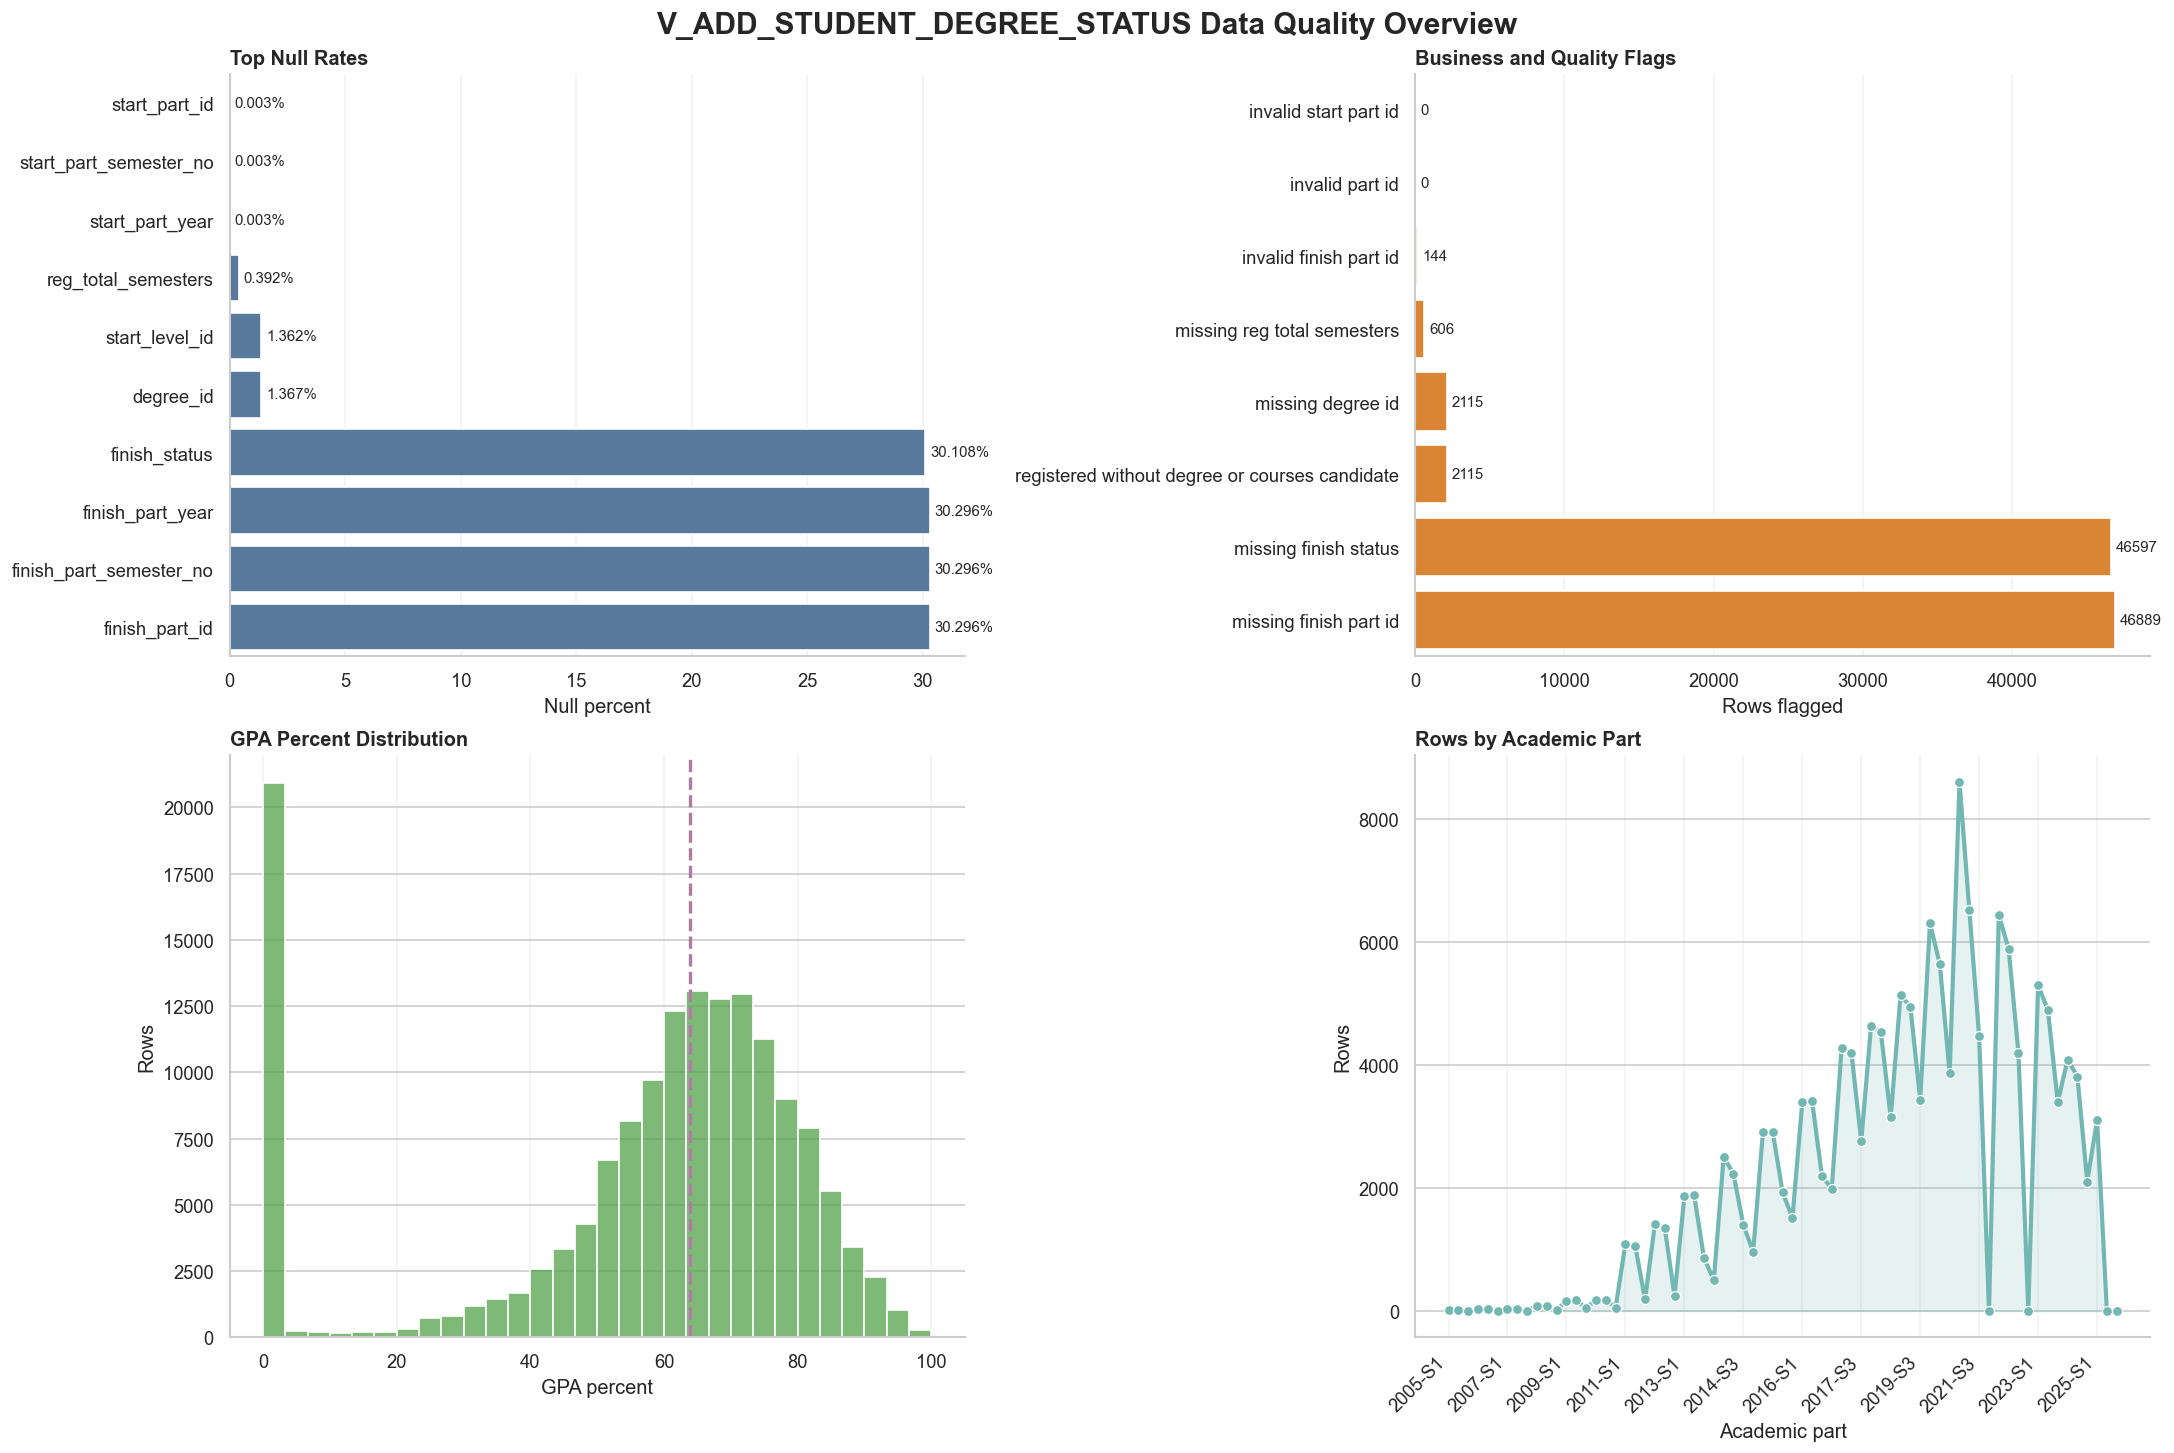

Quality visualization saved: D:\AI\Real projects\Academic_Advisor\data\raw\v_add_student_degree_status_quality_overview.png


In [31]:
# Cell 15: professional data-quality visualizations
# Professional plotting defaults for readable notebook and saved PNG output.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160})

# Plot the operational flags that explain retained nulls and review candidates.
flag_cols_for_plot = [
    "flag_missing_finish_part_id",
    "flag_missing_finish_status",
    "flag_missing_degree_id",
    "flag_registered_without_degree_or_courses_candidate",
    "flag_missing_reg_total_semesters",
    "flag_invalid_part_id",
    "flag_invalid_start_part_id",
    "flag_invalid_finish_part_id",
]

flag_plot_df = pd.DataFrame(
    {
        "quality_flag": flag_cols_for_plot,
        "rows": [int(df_clean[col].fillna(False).sum()) for col in flag_cols_for_plot],
    }
)
flag_plot_df["quality_flag_label"] = (
    flag_plot_df["quality_flag"]
    .str.replace("flag_", "", regex=False)
    .str.replace("_", " ", regex=False)
)
flag_plot_df = flag_plot_df.sort_values("rows", ascending=True)

top_null_plot_df = (
    final_null_report.loc[final_null_report["null_count"] > 0]
    .nlargest(12, "null_percent")
    .sort_values("null_percent", ascending=True)
)

timeline_df = (
    df_clean.groupby(["part_year", "part_semester_no"], dropna=False)
    .size()
    .reset_index(name="rows")
    .sort_values(["part_year", "part_semester_no"])
)
timeline_df["part_label"] = (
    timeline_df["part_year"].astype("string")
    + "-S"
    + timeline_df["part_semester_no"].astype("string")
)
timeline_df["part_order"] = np.arange(len(timeline_df))

# Four-panel overview: nulls, quality flags, GPA distribution, and academic-part volume.
fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle(
    "V_ADD_STUDENT_DEGREE_STATUS Data Quality Overview",
    fontsize=18,
    fontweight="bold",
)

ax = axes[0, 0]
if len(top_null_plot_df):
    sns.barplot(
        data=top_null_plot_df,
        x="null_percent",
        y="column",
        color="#4C78A8",
        ax=ax,
    )
    ax.bar_label(ax.containers[0], fmt="%.3f%%", padding=3, fontsize=9)
    ax.set_xlabel("Null percent")
    ax.set_ylabel("")
else:
    ax.text(0.5, 0.5, "No null values", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()
ax.set_title("Top Null Rates", loc="left", fontweight="bold")

ax = axes[0, 1]
sns.barplot(
    data=flag_plot_df,
    x="rows",
    y="quality_flag_label",
    color="#F58518",
    ax=ax,
)
ax.bar_label(ax.containers[0], fmt="%d", padding=3, fontsize=9)
ax.set_xlabel("Rows flagged")
ax.set_ylabel("")
ax.set_title("Business and Quality Flags", loc="left", fontweight="bold")

ax = axes[1, 0]
sns.histplot(
    data=df_clean,
    x="gpa_percent",
    bins=30,
    color="#54A24B",
    edgecolor="white",
    ax=ax,
)
ax.axvline(df_clean["gpa_percent"].median(), color="#B279A2", linestyle="--", linewidth=2)
ax.set_xlabel("GPA percent")
ax.set_ylabel("Rows")
ax.set_title("GPA Percent Distribution", loc="left", fontweight="bold")

ax = axes[1, 1]
sns.lineplot(
    data=timeline_df,
    x="part_order",
    y="rows",
    marker="o",
    color="#72B7B2",
    linewidth=2.5,
    ax=ax,
)
ax.fill_between(timeline_df["part_order"], timeline_df["rows"], color="#72B7B2", alpha=0.18)
tick_step = max(1, len(timeline_df) // 10)
tick_rows = timeline_df.iloc[::tick_step]
ax.set_xticks(tick_rows["part_order"])
ax.set_xticklabels(tick_rows["part_label"], rotation=45, ha="right")
ax.set_xlabel("Academic part")
ax.set_ylabel("Rows")
ax.set_title("Rows by Academic Part", loc="left", fontweight="bold")

for ax in axes.flat:
    sns.despine(ax=ax)
    ax.grid(axis="x", alpha=0.25)

fig.savefig(ensure_parent(quality_visual_path), bbox_inches="tight")
plt.show()

print("Quality visualization saved:", quality_visual_path)

## Cell 16: Final Summary

The final summary gives the row counts, retained-null counts, duplicate checks, and logical-issue counts needed to confirm that preprocessing followed the approved business rules.


In [32]:
# Cell 16: final summary
summary = pd.DataFrame(
    {
        "metric": [
            "raw_rows",
            "clean_rows",
            "rows_dropped_missing_gpa_agpa",
            "clean_columns",
            "student_status_id_duplicate_rows",
            "full_duplicate_rows",
            "logical_key_duplicate_rows",
            "degree_id_null_rows_retained",
            "finish_part_id_null_rows_retained",
            "finish_status_null_rows_retained",
            "reg_total_semesters_null_rows_retained",
            "invalid_part_id_rows",
            "invalid_start_part_id_rows",
            "invalid_finish_part_id_rows",
            "logical_issue_report_rows",
        ],
        "value": [
            len(df),
            len(df_clean),
            len(dropped_missing_gpa_agpa_report),
            df_clean.shape[1],
            len(duplicate_student_status_id_rows),
            len(full_duplicate_rows),
            len(duplicate_logical_key_rows),
            int(df_clean["flag_missing_degree_id"].fillna(False).sum()),
            int(df_clean["flag_missing_finish_part_id"].fillna(False).sum()),
            int(df_clean["flag_missing_finish_status"].fillna(False).sum()),
            int(df_clean["flag_missing_reg_total_semesters"].fillna(False).sum()),
            int(df_clean["flag_invalid_part_id"].fillna(False).sum()),
            int(df_clean["flag_invalid_start_part_id"].fillna(False).sum()),
            int(df_clean["flag_invalid_finish_part_id"].fillna(False).sum()),
            len(logical_issue_report),
        ],
    }
)

display(summary)

print("Preprocessing complete. Clean dataframe is ready for downstream student semester status, snapshot, and outcome tables.")

,metric,value
0,raw_rows,154779
1,clean_rows,154768
2,rows_dropped_missing_gpa_agpa,11
3,clean_columns,44
4,student_status_id_duplicate_rows,0
5,full_duplicate_rows,0
6,logical_key_duplicate_rows,0
7,degree_id_null_rows_retained,2115
8,finish_part_id_null_rows_retained,46889
9,finish_status_null_rows_retained,46597


Preprocessing complete. Clean dataframe is ready for downstream student semester status, snapshot, and outcome tables.
